In [ ]:
# Import the libraries and split modules used by the main notebook
# matplotlib: display intermediate and final figures
import matplotlib.pyplot as plt
import torch
import numpy as np
import torch.nn as nn
import warnings
import time
import os
from datetime import datetime
from pathlib import Path
from IPython.display import display

from forward_module import Physics_deepwave, SurveyConfig, simulate_observed_data
from functions_module import (
    adjest_deepwave,
    get_dir,
    load_velocity_model,
    save_run_parameters,
    seed_everything,
    train_deepwave,
    weights_init,
)
from network_module import SiameseNetwork, Transfomerdecoder

warnings.filterwarnings('ignore')
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'


In [ ]:
# Cell 2: Check the PyTorch and CUDA environment
# This confirms whether the notebook can use the GPU

print('PyTorch version: ', torch.__version__)
print('CUDA available: ', torch.cuda.is_available())


PyTorch版本:  2.5.1+cu121
CUDA是否可用:  True


In [ ]:
# Select the execution device
# Use cuda:0 if a GPU is available, otherwise use the CPU

gpu_count = torch.cuda.device_count()
print(f'The number of available GPUs is: {gpu_count}')
if torch.cuda.is_available():
    device = torch.device('cuda:0')
    print(f'The selected GPU device is: {torch.cuda.get_device_name(device)}')
else:
    device = torch.device('cpu')
    print('No available GPUs detected, switched to using CPU')


The number of available GPUs is: 1
The selected GPU device is: NVIDIA GeForce RTX 4090


In [ ]:
#  Fix the random seed
# This helps keep initialization and training behavior reproducible

seed_everything(43)


In [ ]:
#  Define the helper used to display and save model figures during training
# It is called every SAVE_FREQ iterations to both save and show the current model

def show_result_figure(m, title, save_path=None):
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    im = ax.imshow(m.detach().cpu().T, cmap='jet', vmin=m.min(), vmax=m.max())
    points = ax.get_position().get_points()
    dy = points[1, 1] - points[0, 1]
    cax = fig.add_axes([0.91, points[0, 1], 0.02, dy])
    cax.yaxis.set_ticks_position('right')
    fig.colorbar(im, cax=cax, orientation='vertical', extend='neither', label='$V_P (m/s)$')
    ax.set_title(title)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    display(fig)
    plt.close(fig)


In [ ]:
# Set file paths, forward parameters, network parameters, and run parameters
# Variable names stay close to the original PIT_FWI.ipynb for easier comparison

'''File_path'''
base_dir = Path.cwd()
True_model_Path = base_dir / 'data' / 'sig2.dat'
Init_model_Path = base_dir / 'data' / 'sigsbee_init_100'

'''Ture_model'''
survey_cfg = SurveyConfig()
vp_true = load_velocity_model(True_model_Path, (201, 225), device)

'''Init_model'''
vp_initial = load_velocity_model(Init_model_Path, (201, 225), device)
vp_initial.requires_grad = True
vp_initial = torch.nn.Parameter(vp_initial)

'''Forward parameters'''
ny = 201
nx = 225
dx = survey_cfg.dx
n_shots = survey_cfg.n_shots
n_sources_per_shot = survey_cfg.n_sources_per_shot
d_source = survey_cfg.d_source
first_source = survey_cfg.first_source
source_depth = survey_cfg.source_depth
n_receivers_per_shot = survey_cfg.n_receivers_per_shot
dz_receiver = survey_cfg.dz_receiver
receiver_depth_start = survey_cfg.receiver_depth_start
freq = survey_cfg.freq
dt = survey_cfg.dt
nt = survey_cfg.nt
peak_time = survey_cfg.peak_time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

'''Network parameters'''
leak_value = 0.00001
D1 = 1

model_shape = [ny, nx]
BATCH_SIZE = 1
N_SHOTS = n_shots
NT = nt
N_RECEIVERS = n_receivers_per_shot
FINAL_OUT_CHANNEL = 1
N_BLOCKS_DECODER = 4
NUM_HEADS = 2
MPL_RATION = 4.0
PATCH_SIZE = (100, 100)
EMBED_DIM = 12
TRANSDDEPTH = 12
DECODER_INITIAL_SHAPE = torch.div(torch.tensor(model_shape), (2 ** (N_BLOCKS_DECODER - 1)), rounding_mode='floor')
FINAL_SIZE_ENCODER = int(BATCH_SIZE * DECODER_INITIAL_SHAPE[0] * DECODER_INITIAL_SHAPE[1])

Physics = Physics_deepwave
train_fun = train_deepwave
adjest_fun = adjest_deepwave

'''Run parameters'''
vp_scale = 1
LR_MILESTONE = 500
ITERATION = 100
lr = 0.004
MINI_BATCHES = n_shots
LAM_PRIOR = 0.0
PRINT_FREQ = 1
SAVE_FREQ = 50

'''adjest parameters'''
fwi_lr = 3
fwi_batch = n_shots
fwi_num_epochs = 0
sim_lr = 1 * 1e-3

'''Save_record_path'''
current_time = datetime.now().strftime('%Y%m%d_%H%M%S')
Path = Path(get_dir(base_dir / 'result' / 'VIT' / f'over_{nx}_{ny}' / f'results_{current_time}'))


In [ ]:
#Print the shapes of the true model and the initial model
# This is a quick check that the data was loaded correctly

print(f'vp_true shape is {vp_true.shape}')
print(f'vp_initial shape is {vp_initial.shape}')


vp_true shape is torch.Size([201, 225])
vp_initial shape is torch.Size([201, 225])


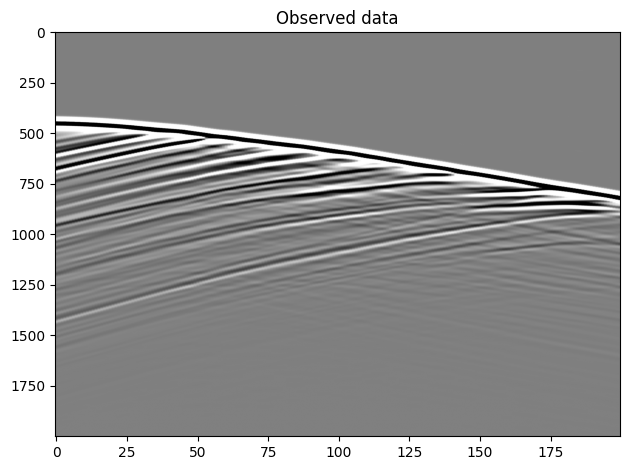

In [ ]:
# Run forward modeling and display the observed data
# Training later tries to make the predicted model reproduce these records

d_obs, source_locations, receiver_locations, source_amplitudes = simulate_observed_data(
    vp_true=vp_true,
    config=survey_cfg,
    device=device,
)
plt.imshow(d_obs.squeeze().cpu().numpy()[0], cmap='gray', aspect='auto', vmax=0.1, vmin=-0.1)
plt.title('Observed data')
plt.tight_layout()
plt.show()


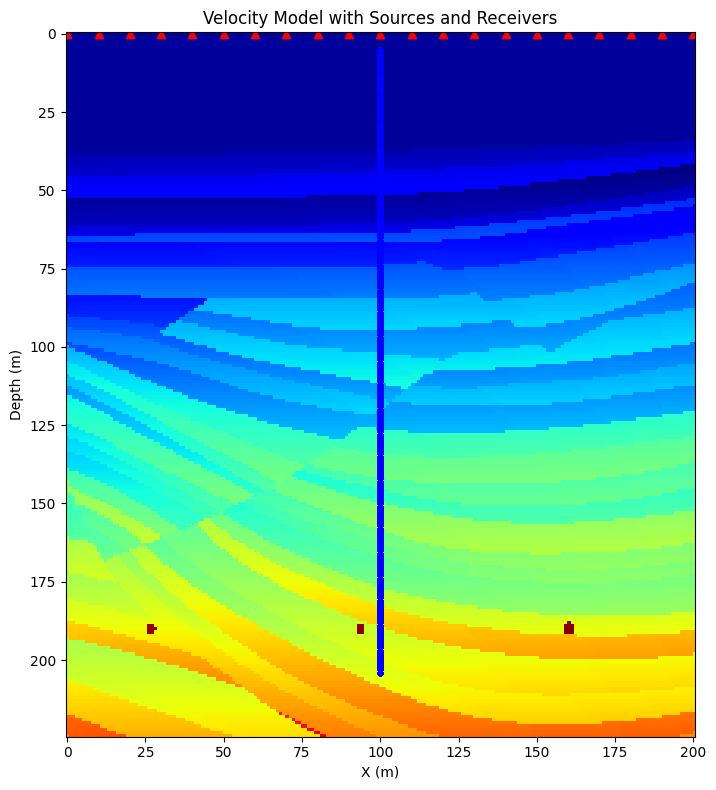

In [ ]:
#Display the velocity model and acquisition geometry
# Red triangles are sources and blue dots are receivers

if isinstance(vp_true, torch.Tensor):
    vel_np = vp_true.detach().cpu().numpy().T
else:
    vel_np = vp_true.T

plt.figure(figsize=(10, 8))
plt.imshow(vel_np, cmap='jet')
source_x = source_locations[:, 0, 0].detach().cpu().numpy()
source_z = source_locations[:, 0, 1].detach().cpu().numpy()
plt.scatter(source_x, source_z, c='red', marker='^', label='Sources')
receiver_x = receiver_locations[:, :, 0].detach().cpu().numpy()
receiver_z = receiver_locations[:, :, 1].detach().cpu().numpy()
plt.scatter(receiver_x.flatten(), receiver_z.flatten(), c='blue', marker='o', s=10, label='Receivers')
plt.xlabel('X (m)')
plt.ylabel('Depth (m)')
plt.title('Velocity Model with Sources and Receivers')
plt.tight_layout()
plt.show()


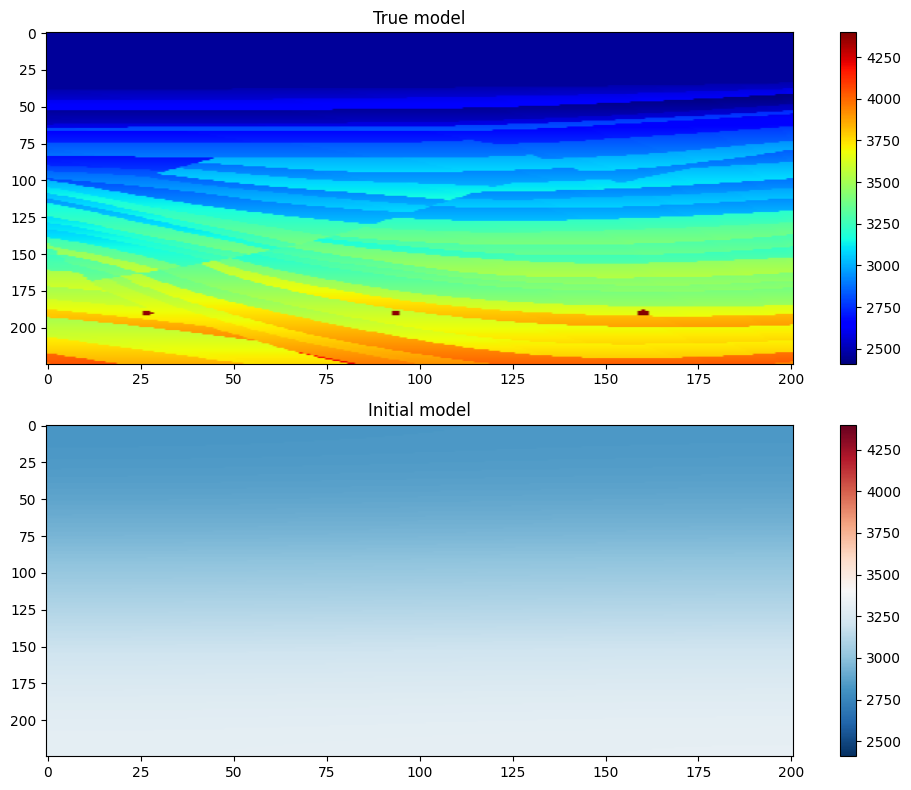

In [ ]:
#  Display the true model and the initial model
# This gives a visual comparison before training starts

get_dir(Path)
vmin = np.min(vp_true.cpu().numpy())
vmax = np.max(vp_true.cpu().numpy())
plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.imshow(vp_true.cpu().numpy().T, cmap='jet', aspect='auto')
plt.colorbar()
plt.title('True model')
plt.subplot(2, 1, 2)
plt.imshow(vp_initial.detach().cpu().numpy().T, cmap='RdBu_r', aspect='auto', vmax=vmax, vmin=vmin)
plt.colorbar()
plt.title('Initial model')
plt.tight_layout()
plt.show()


Iteration 1 ===== loss: 0.06209337196889378 for data and 257.4815673828125 for model
Iteration 2 ===== loss: 0.06135971063659305 for data and 257.2501525878906 for model
Iteration 3 ===== loss: 0.05994999887687819 for data and 256.4327087402344 for model
Iteration 4 ===== loss: 0.05976387680996032 for data and 258.3045349121094 for model
Iteration 5 ===== loss: 0.05925354414752552 for data and 258.60821533203125 for model
Iteration 6 ===== loss: 0.05815663295132773 for data and 259.15740966796875 for model
Iteration 7 ===== loss: 0.05748244144377254 for data and 259.4027099609375 for model
Iteration 8 ===== loss: 0.056219414940902164 for data and 262.4644775390625 for model
Iteration 9 ===== loss: 0.056109226175716946 for data and 261.0694274902344 for model
Iteration 10 ===== loss: 0.05585462564513797 for data and 259.1314697265625 for model
Iteration 11 ===== loss: 0.05565502494573593 for data and 262.1058654785156 for model
Iteration 12 ===== loss: 0.056312396590198786 for data and 

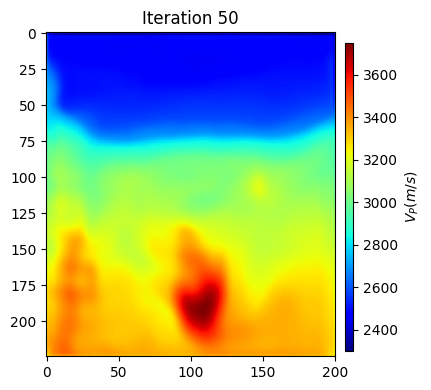

Iteration 51 ===== loss: 0.011648188877318586 for data and 141.82073974609375 for model
Iteration 52 ===== loss: 0.011486492607565154 for data and 139.90821838378906 for model
Iteration 53 ===== loss: 0.011455483025028593 for data and 136.98753356933594 for model
Iteration 54 ===== loss: 0.011289185666967006 for data and 135.42172241210938 for model
Iteration 55 ===== loss: 0.011056564482195037 for data and 135.56088256835938 for model
Iteration 56 ===== loss: 0.01085683521592901 for data and 133.93368530273438 for model
Iteration 57 ===== loss: 0.010873244365765936 for data and 135.13172912597656 for model
Iteration 58 ===== loss: 0.010583445075012389 for data and 132.92929077148438 for model
Iteration 59 ===== loss: 0.010607261210680008 for data and 132.34967041015625 for model
Iteration 60 ===== loss: 0.010445971707148212 for data and 133.95431518554688 for model
Iteration 61 ===== loss: 0.010337842938800653 for data and 133.30397033691406 for model
Iteration 62 ===== loss: 0.010217

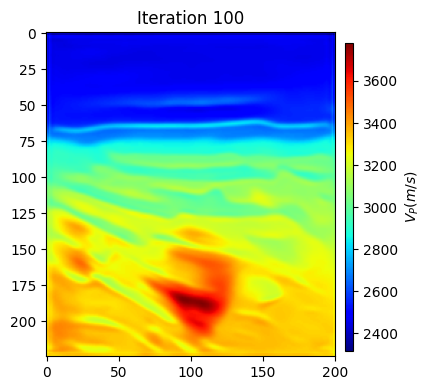

In [11]:
# Cell 11: Build the main network and run first-stage training
# Save one model snapshot every 50 iterations and show it in the notebook

criteria = torch.nn.L1Loss()
autoencoder = Transfomerdecoder(
    batch_size=BATCH_SIZE,
    in_channels=N_SHOTS,
    nt=NT,
    nr=N_RECEIVERS,
    patch_size=PATCH_SIZE,
    embed_dim=EMBED_DIM,
    transddepth=TRANSDDEPTH,
    n_blocks_decoder=N_BLOCKS_DECODER,
    final_size_encoder=FINAL_SIZE_ENCODER,
    initial_shape_decoder=DECODER_INITIAL_SHAPE,
    final_spatial_shape=model_shape,
    num_heads=NUM_HEADS,
    mlp_ratio=MPL_RATION,
)
autoencoder = autoencoder.to(device=device)
optim_autoencoder = torch.optim.Adam(autoencoder.parameters(), lr=lr, betas=(0.5, 0.9))

all_loss_data = []
all_loss_model = []
all_loss_prior = []

t_start = time.time()

for iter in range(ITERATION):
    loss_data, m, autoencoder = train_fun(
        Physics=Physics,
        autoencoder=autoencoder,
        d_obs=d_obs,
        optim_autoencoder=optim_autoencoder,
        vp_initial=vp_initial,
        vp_scale=vp_scale,
        criteria=criteria,
        mini_batches=MINI_BATCHES,
        src_loc=source_locations,
        rec_loc=receiver_locations,
        src=source_amplitudes,
        dx=dx,
        dt=dt,
        pml_freq=freq,
    )

    all_loss_data.append(loss_data)
    with torch.no_grad():
        all_loss_model.append(criteria(m, vp_true).item())
    if (iter + 1) % PRINT_FREQ == 0:
        print(f'Iteration {iter + 1} ===== loss: {all_loss_data[-1]} for data and {all_loss_model[-1]} for model')
    if (iter + 1) % SAVE_FREQ == 0:
        np.save(Path / f'model{iter + 1}.npy', m.detach().cpu().T)
        np.save(Path / 'loss.npy', np.asarray(all_loss_data))
        show_result_figure(m, f'Iteration {iter + 1}', Path / f'model{iter + 1}.png')


In [ ]:
# Initialize second-stage optimization variables
# If fwi_num_epochs = 0, this cell only prepares the stage-two setup

np.save(Path / 'vel_init_reparameter.npy', m.detach().cpu().numpy())
data = np.load(Path / 'vel_init_reparameter.npy')
model = torch.from_numpy(data).to(device)
model.requires_grad = True
d_model = torch.nn.Parameter(model)

netD = SiameseNetwork(D1)
netD = netD.apply(lambda d_model: weights_init(d_model, leak_value))
netD = netD.to(device)

optim_vel = torch.optim.Adam([{'params': d_model, 'lr': fwi_lr, 'betas': (0.5, 0.99), 'eps': 1e-8, 'weight_decay': 0}])
optim_net = torch.optim.Adam(netD.parameters(), lr=sim_lr, betas=(0.5, 0.99), eps=1e-6, weight_decay=0)

for iter in range(ITERATION, ITERATION + fwi_num_epochs):
    loss_data, optim_vel, optim_net = adjest_fun(
        Physics=Physics,
        netD=netD,
        d_model=d_model,
        d_obs=d_obs,
        mini_batches=MINI_BATCHES,
        optim_vel=optim_vel,
        optim_net=optim_net,
        src_loc=source_locations,
        rec_loc=receiver_locations,
        src=source_amplitudes,
        dx=dx,
        dt=dt,
        pml_freq=freq,
    )

    all_loss_data.append(loss_data)
    ref_model_loss = all_loss_model[-1] if all_loss_model else None
    if (iter + 1) % PRINT_FREQ == 0:
        print(f'Iteration {iter + 1} ===== loss: {all_loss_data[-1]} for data and {ref_model_loss} for model')
    if (iter + 1) % SAVE_FREQ == 0:
        np.save(Path / f'model{iter + 1}.npy', d_model.detach().cpu().T)
        show_result_figure(d_model, f'Iteration {iter + 1}', Path / f'model{iter + 1}.png')


In [ ]:
# Save final results, parameters, and comparison plots
# Create the final comparison among the true, stage-one, and learned models

get_dir(Path)
plt.figure(figsize=(8, 8))
plt.subplot(3, 1, 1)
plt.imshow(vp_true.cpu().numpy().T, cmap='jet', aspect='auto')
plt.colorbar()
plt.title('True model')
plt.subplot(3, 1, 2)
plt.imshow(m.detach().cpu().numpy().T, cmap='jet', aspect='auto')
plt.colorbar()
plt.title('Initial model')
plt.subplot(3, 1, 3)
plt.imshow(d_model.detach().cpu().numpy().T, cmap='jet', aspect='auto')
plt.colorbar()
plt.title('Learned model')
plt.tight_layout()
plt.savefig(Path / 'true_initial_learned.png')
plt.show()

np.save(Path / 'all_loss_data.npy', np.asarray(all_loss_data))
np.save(Path / 'all_loss_model.npy', np.asarray(all_loss_model))
np.save(Path / 'd_model.npy', d_model.detach().cpu().numpy())

elapsed_time = time.time() - t_start
params = {
    'Model Shape': {'ny': ny, 'nx': nx, 'dx': dx},
    'Forward Parameters': {
        'n_shots': n_shots,
        'n_sources_per_shot': n_sources_per_shot,
        'd_source': d_source,
        'first_source': first_source,
        'source_depth': source_depth,
        'n_receivers_per_shot': n_receivers_per_shot,
        'dz_receiver': dz_receiver,
        'receiver_depth_start': receiver_depth_start,
        'freq': freq,
        'dt': dt,
        'nt': nt,
        'peak_time': peak_time,
    },
    'Network Parameters': {
        'model_shape': model_shape,
        'BATCH_SIZE': BATCH_SIZE,
        'N_SHOTS': N_SHOTS,
        'NT': NT,
        'N_RECEIVERS': N_RECEIVERS,
        'FINAL_OUT_CHANNEL': FINAL_OUT_CHANNEL,
        'N_BLOCKS_DECODER': N_BLOCKS_DECODER,
        'NUM_HEADS': NUM_HEADS,
        'MPL_RATION': MPL_RATION,
        'PATCH_SIZE': PATCH_SIZE,
        'EMBED_DIM': EMBED_DIM,
        'TRANSDDEPTH': TRANSDDEPTH,
    },
    'Run Parameters': {
        'vp_scale': vp_scale,
        'LR_MILESTONE': LR_MILESTONE,
        'ITERATION': ITERATION,
        'lr': lr,
        'MINI_BATCHES': MINI_BATCHES,
        'LAM_PRIOR': LAM_PRIOR,
        'PRINT_FREQ': PRINT_FREQ,
        'SAVE_FREQ': SAVE_FREQ,
    },
    'adjest parameters': {
        'fwi_lr': fwi_lr,
        'fwi_batch': fwi_batch,
        'fwi_num_epochs': fwi_num_epochs,
        'sim_lr': sim_lr,
    },
    'loss': {
        'loss_data': all_loss_data[-1] if all_loss_data else None,
    },
    'time': {
        'Running complete in': elapsed_time,
    },
}

save_run_parameters(Path / 'parameters.txt', params)
print('Running complete in {:.0f}m  {:.0f}s'.format(elapsed_time // 60, elapsed_time % 60))
